# Omega60 laser sampling

In [658]:
import matplotlib.pyplot as plt
import scipy as sp
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import uniform
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import pandas as pd
import pyvista as pv
from scipy.stats import norm
import scipy.stats as stats 


## Support functions

### Conversion

In [659]:
def sph_to_cart(r, theta, phi):
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    return np.array([x, y, z])

def cart_to_sph(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(z / r)
    phi = np.pi + np.arctan2(y, x)
    return np.array([r, theta, phi])

### Spherical function plotter

In [660]:
def plot_spherical_function(theta, phi, f, name='f', title="Spherical Function"):
  f_flat = f.ravel()

  xs, ys, zs = sph_to_cart(1.0, theta, phi)
  points = np.column_stack((xs.ravel(), ys.ravel(), zs.ravel()))
  f_flat = f.ravel()

  cloud = pv.PolyData(points)
  cloud[name] = f_flat

  plotter = pv.Plotter()
  plotter.add_mesh(cloud, render_points_as_spheres=True, point_size=10, scalars=name, cmap='plasma')
  plotter.add_scalar_bar(title=name, vertical=True)

  return plotter

### Plotter of sectors given theta and phi

In [661]:
def plot_spherical_sectors( theta, phi, fs, name='func', title="Spherical Sectors" ):

  func = sp.interpolate.RegularGridInterpolator( (theta, phi), fs, method='nearest', bounds_error=False, fill_value=0.0 )

  sphere = pv.Sphere( theta_resolution=100, phi_resolution=100 )
  r, ts, ps = cart_to_sph( sphere.points[:,0], sphere.points[:,1], sphere.points[:,2] )
  sphere['Data'] = func( ( ts, ps, ) )

  plotter = pv.Plotter()
  plotter.add_mesh(sphere, scalar_bar_args={'title': 'Z Position'})
  
  return plotter

### Sample of random laser points in a 2D window distribution normale

In [662]:
def sample_window( t1, t2, l1=1., l2=1., center=np.array([ 0., 0., 0., ]), num_points=1000, dist = lambda num_points: sp.stats.uniform.rvs( loc=-1.0, scale=2.0, size=( num_points, 2, ) ), ):
  # sample distribution 
  sample = np.zeros( (num_points, 2,) )
  k = 0
  while k < num_points:
    s = dist(1)
    if np.abs(s[0,0]) <= 1.0 and np.abs(s[0,1]) <= 1.0:
      sample[k,:] = s[0,:]
      k += 1
  # map to the window
  v1 = 0.5 * l1 * t1 / np.linalg.norm( t1 )
  v2 = 0.5 * l2 * t2 / np.linalg.norm( t2 )
  return center + sample[:,0,None] * v1 + sample[:,1,None] * v2

In [663]:
t1 = np.array([ 0., 1., 0., ]) # ey
t2 = np.array([ 0., 0., 1., ]) # ez

xs = sample_window( t1, t2, l1=2., l2=2., center=np.array([ 0., 0., 0., ]), num_points=1000, )

focus = np.array([ 1., 0., 0., ])
us = focus - xs
us = us / np.linalg.norm( us, axis=1 )[:,None]

print(xs.shape)

(1000, 3)


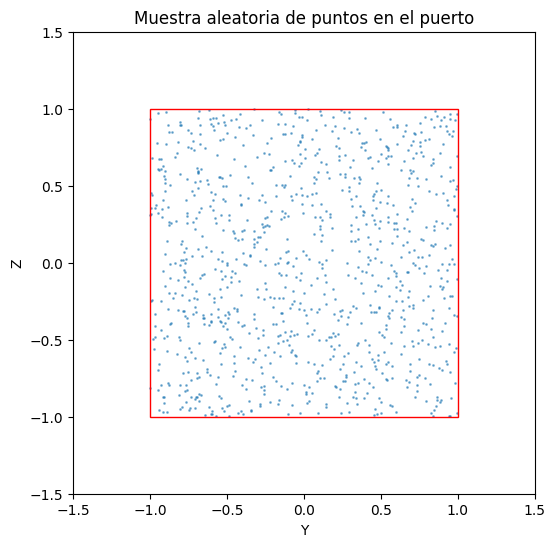

In [664]:
fig, ax = plt.subplots(figsize=(6,6))

ax.scatter( xs[:,1], xs[:,2], s=1, alpha=0.5 )

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')

ax.set_title("Muestra aleatoria de puntos en el puerto")
ax.set_xlabel("Y")
ax.set_ylabel("Z")

rect = plt.Rectangle( (-1,-1), 2, 2, linewidth=1, edgecolor='r', facecolor='none' )
ax.add_patch(rect)

### Use of normal distribution in the sample of points distribution Gaussienne

In [665]:
dist = lambda num_points: sp.stats.norm(loc=0.0, scale=0.5).rvs(size=(num_points, 2))
xs = sample_window( t1, t2, l1=2., l2=2., center=np.array([ 0., 0., 0., ]), num_points=10000, dist=dist )
print(xs.shape  )

(10000, 3)


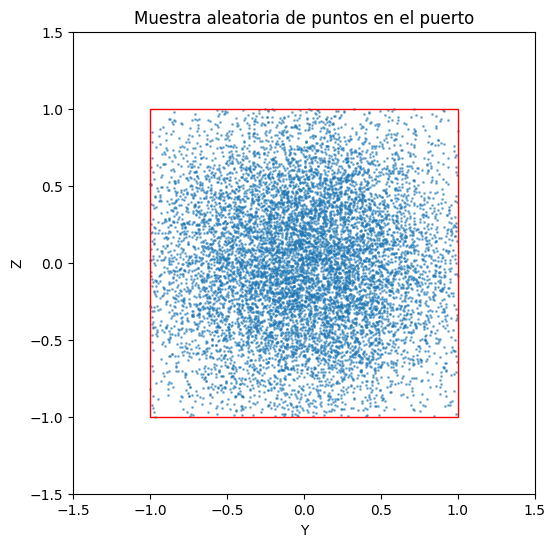

In [666]:
fig, ax = plt.subplots(figsize=(6,6))

ax.scatter( xs[:,1], xs[:,2], s=1, alpha=0.5 )

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')

ax.set_title("Muestra aleatoria de puntos en el puerto")
ax.set_xlabel("Y")
ax.set_ylabel("Z")

rect = plt.Rectangle( (-1,-1), 2, 2, linewidth=1, edgecolor='r', facecolor='none' )
ax.add_patch(rect)

## Chamber and target geometry parameters

In [667]:
BEAM_RADIUS = 0.14 #meters
TARGET_RADIUS = 0.000605 #meters 
CHAMBER_RADIUS = 1.65 #meters 
WINDOW_SIZE = 0.30 #meters

## Define geometry and focal distances

### Define and create beams based on Omega 60 

In [668]:
def get_omega_dataframe():
    """
    Constructs the master database for OMEGA-60 laser parameters.
    Calculates local coordinate systems (tangent and normal vectors) for each beam,
    ensuring compatibility with ARWEN simulation requirements.
    """
    # --- 1. Physical Configuration ---
    DEFAULT_ENERGY = 500.0     # Default beam energy [Joules]
    WAVELENGTH = 351e-9        # UV laser wavelength [351 nm]

    # OMEGA-60 port configuration: (Theta_deg, Beam_Count, Phi_Offset_deg)
    # Based on the standard 60-beam direct-drive geometry.
    omega_config = [
        (23.2, 6, 0), (47.8, 12, 15), (59.1, 12, 0),   # Northern Hemisphere
        (120.9, 12, 0), (132.2, 12, 15), (156.8, 6, 0) # Southern Hemisphere
    ]

    all_data = []
    beam_count = 1

    for theta_deg, num_beams, phi_offset in omega_config:
        # Uniform azimuthal distribution over 360°
        phis_deg = np.linspace(0, 360, num_beams, endpoint=False) + phi_offset
        
        for phi_deg in phis_deg:
            # --- 2. Geometric Coordinate Transformation ---
            # Conversion to radians for NumPy trigonometric functions
            theta_rad = np.deg2rad(theta_deg)
            phi_rad = np.deg2rad(phi_deg % 360)
            
            # Unit normal vector (beam propagation direction)
            # In a center-aligned sphere, the normal is the radial vector
            nx = np.sin(theta_rad) * np.cos(phi_rad)
            ny = np.sin(theta_rad) * np.sin(phi_rad)
            nz = np.cos(theta_rad)
            normal_u = np.array([nx, ny, nz])
            
            # Position of the port center on the chamber wall
            center = normal_u * CHAMBER_RADIUS

            # --- 3. Local Tangent Basis Calculation (t1, t2) ---
            # t1: Azimuthal direction vector (East-West alignment)
            t1 = np.array([-np.sin(phi_rad), np.cos(phi_rad), 0.0])
            
            # Singularity handling at the poles (if t1 is null)
            if np.linalg.norm(t1) < 1e-6: 
                t1 = np.array([1, 0, 0])
            t1 /= np.linalg.norm(t1)
            
            # t2: Polar direction vector (North-South alignment) via cross product
            # Completes the orthogonal right-handed coordinate system (t1, t2, normal)
            t2 = np.cross(normal_u, t1)
            t2 /= np.linalg.norm(t2)

            # --- 4. Data Record Assembly (Standardized Format) ---
            all_data.append({
                'port': f'OMEGA_J{beam_count:02d}',
                'subwindow': 0,              # Specific to OMEGA (unlike NIF quads)
                'LAT_rad': theta_rad,        # Latitude (Theta) in radians
                'LONG_rad': phi_rad,         # Longitude (Phi) in radians
                'color': 'blue' if theta_deg < 90 else 'red',
                'energy': DEFAULT_ENERGY,
                'wavelength': WAVELENGTH,
                'center': center,            # Numpy array [x, y, z]
                'normal': normal_u,          # Numpy unit vector [nx, ny, nz]
                't1': t1,                    # First tangent vector
                't2': t2,                    # Second tangent vector
                'beam_radius': BEAM_RADIUS,
                'focus': None                # Placeholder for focusing parameters
            })
            beam_count += 1

    return pd.DataFrame(all_data)

# --- EXECUTION ---
df_omega = get_omega_dataframe()

# Data verification
print(f"Generated columns: {df_omega.columns.tolist()}")
df_omega.head()

Generated columns: ['port', 'subwindow', 'LAT_rad', 'LONG_rad', 'color', 'energy', 'wavelength', 'center', 'normal', 't1', 't2', 'beam_radius', 'focus']


,port,subwindow,LAT_rad,LONG_rad,color,energy,wavelength,center,normal,t1,t2,beam_radius,focus
0,OMEGA_J01,0,0.404916,0.000000,blue,500.0,3.510000e-07,"[0.6500041508250692, 0.0, 1.5165733097711367]","[0.3939419095909511, 0.0, 0.9191353392552344]","[-0.0, 1.0, 0.0]","[-0.9191353392552345, -0.0, 0.39394190959095116]",0.14,None
1,OMEGA_J02,0,0.404916,1.047198,blue,500.0,3.510000e-07,"[0.32500207541253473, 0.5629201071798418, 1.51...","[0.1969709547954756, 0.34116370132111623, 0.91...","[-0.8660254037844386, 0.5000000000000001, 0.0]","[-0.45956766962761736, -0.7959945533110614, 0....",0.14,None
2,OMEGA_J03,0,0.404916,2.094395,blue,500.0,3.510000e-07,"[-0.3250020754125345, 0.5629201071798419, 1.51...","[-0.19697095479547547, 0.3411637013211163, 0.9...","[-0.8660254037844388, -0.49999999999999983, 0.0]","[0.459567669627617, -0.7959945533110615, 0.393...",0.14,None
3,OMEGA_J04,0,0.404916,3.141593,blue,500.0,3.510000e-07,"[-0.6500041508250692, 7.960255027404145e-17, 1...","[-0.3939419095909511, 4.8243969863055425e-17, ...","[-1.2246467991473532e-16, -1.0, 0.0]","[0.9191353392552345, -1.1256161512021395e-16, ...",0.14,None
4,OMEGA_J05,0,0.404916,4.188790,blue,500.0,3.510000e-07,"[-0.3250020754125349, -0.5629201071798416, 1.5...","[-0.19697095479547572, -0.3411637013211162, 0....","[0.8660254037844385, -0.5000000000000004, 0.0]","[0.4595676696276176, 0.7959945533110612, 0.393...",0.14,None


### Define focal point

In [669]:
def compute_focal_distance(defocus_mm=0.0):
    """
    Calculates the focal distance required to achieve a specific beam spot size.
    A positive defocus (in mm) shifts the focal point beyond the target center, 
    widening the irradiation area to improve illumination uniformity.
    """
    # Convert defocus from mm to meters and calculate the effective target radius
    # This accounts for the beam divergence/convergence at the target surface.
    effective_target_radius = TARGET_RADIUS + (defocus_mm / 1000.0) 
    
    # Using Thales' theorem (intercept theorem) to determine the focal length (f_window)
    # relative to the chamber geometry and beam aperture.
    f_window = (WINDOW_SIZE * CHAMBER_RADIUS) / (WINDOW_SIZE - effective_target_radius)
    return f_window

def compute_focus_position(port_center, f_window):
    """
    Computes the 3D coordinates of the focal point along the beam's optical axis.
    """
    # Normal unit vector pointing from the port center toward the chamber origin (0,0,0)
    propagation_vector = port_center / np.linalg.norm(port_center)
    
    # Position the focal point along the optical axis at distance f_window
    focal_point_pos = port_center - (propagation_vector * f_window)
    return focal_point_pos

def assign_beam_focus(beam_row):
    """
    Helper function to apply a standardized defocus to a specific beam port.
    A 2.0mm defocus is typically used to over-fill the target and reduce intensity peaks.
    """
    f_dist = compute_focal_distance(defocus_mm=2) 
    return compute_focus_position(beam_row["center"], f_dist)


# =====================================================
# Beam Focus Assignment Pipeline
# =====================================================

# 1. Generate the master configuration DataFrame
df_omega = get_omega_dataframe()

# 2. Compute 3D focal points for all beams using a vectorized approach (Pandas apply)
# This replaces manual loops with a more robust and scalable implementation.
df_omega['focus'] = df_omega.apply(assign_beam_focus, axis=1)

# 3. Final verification of the focus coordinates
df_omega.head()

,port,subwindow,LAT_rad,LONG_rad,color,energy,wavelength,center,normal,t1,t2,beam_radius,focus
0,OMEGA_J01,0,0.404916,0.000000,blue,500.0,3.510000e-07,"[0.6500041508250692, 0.0, 1.5165733097711367]","[0.3939419095909511, 0.0, 0.9191353392552344]","[-0.0, 1.0, 0.0]","[-0.9191353392552345, -0.0, 0.39394190959095116]",0.14,"[-0.005693642505419816, 0.0, -0.01328426325914..."
1,OMEGA_J02,0,0.404916,1.047198,blue,500.0,3.510000e-07,"[0.32500207541253473, 0.5629201071798418, 1.51...","[0.1969709547954756, 0.34116370132111623, 0.91...","[-0.8660254037844386, 0.5000000000000001, 0.0]","[-0.45956766962761736, -0.7959945533110614, 0....",0.14,"[-0.002846821252709908, -0.004930839049760438,..."
2,OMEGA_J03,0,0.404916,2.094395,blue,500.0,3.510000e-07,"[-0.3250020754125345, 0.5629201071798419, 1.51...","[-0.19697095479547547, 0.3411637013211163, 0.9...","[-0.8660254037844388, -0.49999999999999983, 0.0]","[0.459567669627617, -0.7959945533110615, 0.393...",0.14,"[0.002846821252709908, -0.004930839049760438, ..."
3,OMEGA_J04,0,0.404916,3.141593,blue,500.0,3.510000e-07,"[-0.6500041508250692, 7.960255027404145e-17, 1...","[-0.3939419095909511, 4.8243969863055425e-17, ...","[-1.2246467991473532e-16, -1.0, 0.0]","[0.9191353392552345, -1.1256161512021395e-16, ...",0.14,"[0.005693642505419816, -6.972701069751618e-19,..."
4,OMEGA_J05,0,0.404916,4.188790,blue,500.0,3.510000e-07,"[-0.3250020754125349, -0.5629201071798416, 1.5...","[-0.19697095479547572, -0.3411637013211162, 0....","[0.8660254037844385, -0.5000000000000004, 0.0]","[0.4595676696276176, 0.7959945533110612, 0.393...",0.14,"[0.0028468212527099634, 0.004930839049760438, ..."


### Creates data frame of complete beam geometry and data

In [670]:
# 1. We use the 'df_omega' DataFrame we just created and filled with focus data
# No need to create a new DataFrame from a list anymore!

# 2. Define OMEGA beam dimensions
# For OMEGA, the beam diameter is typically 28cm (0.28m)
df_omega['l1'] = 0.28
df_omega['l2'] = 0.28

# 3. Function to split vector columns [x, y, z] into three separate columns
def expand_vector_column(df, column_name):
    # Create a temporary DataFrame from the list of coordinates
    # .tolist() is used because these columns contain numpy arrays
    temp = pd.DataFrame(df[column_name].tolist(), index=df.index)
    temp.columns = [f'{column_name}_x', f'{column_name}_y', f'{column_name}_z']
    return temp

# 4. Expand all geometric vector columns
# This "flattens" the data so ARWEN can read it easily
df_centers = expand_vector_column(df_omega, 'center')
df_t1      = expand_vector_column(df_omega, 't1')
df_t2      = expand_vector_column(df_omega, 't2')
df_normal  = expand_vector_column(df_omega, 'normal')
df_focus   = expand_vector_column(df_omega, 'focus')

# 5. Assemble the final Master Table
# We select the metadata and join it with the expanded coordinates
data_columns = ['port', 'subwindow', 'LAT_rad', 'LONG_rad', 'color', 'energy', 'wavelength', 'l1', 'l2']

df_omega_final = pd.concat([
    df_omega[data_columns],
    df_centers, 
    df_t1, 
    df_t2, 
    df_normal, 
    df_focus
], axis=1)

# 6. Aesthetic renaming for clarity
df_omega_final = df_omega_final.rename(columns={'LAT_rad': 'LAT', 'LONG_rad': 'LONG'})

# 7. Display the result
print(f"Final OMEGA-60 table generated with {len(df_omega_final)} rows.")
df_omega_final.head(10)

Final OMEGA-60 table generated with 60 rows.


,port,subwindow,LAT,LONG,color,energy,wavelength,l1,l2,center_x,...,t1_z,t2_x,t2_y,t2_z,normal_x,normal_y,normal_z,focus_x,focus_y,focus_z
0,OMEGA_J01,0,0.404916,0.000000,blue,500.0,3.510000e-07,0.28,0.28,0.650004,...,0.0,-0.919135,-0.000000e+00,0.393942,0.393942,0.000000e+00,0.919135,-0.005694,0.000000e+00,-0.013284
1,OMEGA_J02,0,0.404916,1.047198,blue,500.0,3.510000e-07,0.28,0.28,0.325002,...,0.0,-0.459568,-7.959946e-01,0.393942,0.196971,3.411637e-01,0.919135,-0.002847,-4.930839e-03,-0.013284
2,OMEGA_J03,0,0.404916,2.094395,blue,500.0,3.510000e-07,0.28,0.28,-0.325002,...,0.0,0.459568,-7.959946e-01,0.393942,-0.196971,3.411637e-01,0.919135,0.002847,-4.930839e-03,-0.013284
3,OMEGA_J04,0,0.404916,3.141593,blue,500.0,3.510000e-07,0.28,0.28,-0.650004,...,0.0,0.919135,-1.125616e-16,0.393942,-0.393942,4.824397e-17,0.919135,0.005694,-6.972701e-19,-0.013284
4,OMEGA_J05,0,0.404916,4.188790,blue,500.0,3.510000e-07,0.28,0.28,-0.325002,...,0.0,0.459568,7.959946e-01,0.393942,-0.196971,-3.411637e-01,0.919135,0.002847,4.930839e-03,-0.013284
5,OMEGA_J06,0,0.404916,5.235988,blue,500.0,3.510000e-07,0.28,0.28,0.325002,...,0.0,-0.459568,7.959946e-01,0.393942,0.196971,-3.411637e-01,0.919135,-0.002847,4.930839e-03,-0.013284
6,OMEGA_J07,0,0.834267,0.261799,blue,500.0,3.510000e-07,0.28,0.28,1.180678,...,0.0,-0.648832,-1.738541e-01,0.740805,0.715562,1.917343e-01,0.671721,-0.010342,-2.771136e-03,-0.009708
7,OMEGA_J08,0,0.834267,0.785398,blue,500.0,3.510000e-07,0.28,0.28,0.864316,...,0.0,-0.474978,-4.749782e-01,0.740805,0.523828,5.238280e-01,0.671721,-0.007571,-7.570886e-03,-0.009708
8,OMEGA_J09,0,0.834267,1.308997,blue,500.0,3.510000e-07,0.28,0.28,0.316362,...,0.0,-0.173854,-6.488323e-01,0.740805,0.191734,7.155623e-01,0.671721,-0.002771,-1.034202e-02,-0.009708
9,OMEGA_J10,0,0.834267,1.832596,blue,500.0,3.510000e-07,0.28,0.28,-0.316362,...,0.0,0.173854,-6.488323e-01,0.740805,-0.191734,7.155623e-01,0.671721,0.002771,-1.034202e-02,-0.009708


## Impacts of the laser beams from window to a target sphere

### Calculates hits on sphere

In [671]:
def hit_sphere( x, u, radius, center=np.array([0.,0.,0.,]), ):
  
  dx = x - center

  # Coeficientes de la ecuación cuadrática
  A = u[0]**2 + u[1]**2 + u[2]**2 
  B = 2*(dx[0]*u[0] + dx[1]*u[1] + dx[2]*u[2])
  C = dx[0]**2 + dx[1]**2 + dx[2]**2 - radius**2

  disc = B*B - 4*A*C

  # Calcular puntos de intersección (si existen)
  if disc < 0:
    return []
  elif disc == 0:
    return [ -0.5 * B / A ] 
  else:
    disc = np.sqrt(disc)
    l1 = 0.5 * (-B + disc) / A
    l2 = 0.5 * (-B - disc) / A
    return [ l1, l2, ]

### Collects impact information

In [672]:
def ray_hit_on_sphere( x, u, radius, center=np.array([0.,0.,0.,]), ):

  ls = hit_sphere( x, u, radius=radius, center=center, )
  
  if len(ls) == 0:
    return -1.
  elif len(ls) == 1:
    if ls[0] < 0:
      return -1.
    else:
      return ls[0]
  else:
    l1, l2 = ls
    if l1 < 0 and l2 < 0:
      return -1.
    elif l1 > 0 and l2 > 0:
      return min(l1, l2)
    else:
      return max(l1, l2)
    

  
def ray_hit( x, u, radius, center=np.array([0.,0.,0.,]), ):
  l = ray_hit_on_sphere( x, u, radius=radius, center=center, ) # Longitud de impacto
  xsph = x + l * u 
  n = ( xsph - center ) / np.linalg.norm( xsph - center )
  cs = np.dot( n, u) / np.linalg.norm(u)
  return [ x, u, l, xsph, cs, cart_to_sph( xsph[0], xsph[1], xsph[2] ), n, ] # Devuelve r, theta, phi del punto

### Validation of hits on sphere

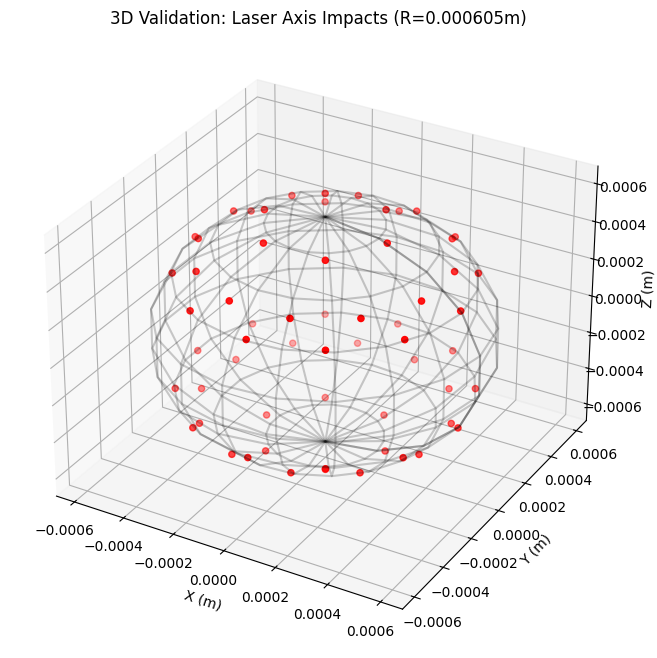

In [673]:
# Initialize a list to store the coordinates of successful impacts
hits = []

# Iterate through each laser beam in the dataset
for i, row in df_omega.iterrows():
    # 1. Retrieve the starting position (port center) and the target focal point
    x = row["center"]
    focus = row["focus"]
    
    # 2. Compute the normalized direction vector (unit vector) from port to focus
    u = focus - x
    u = u / np.linalg.norm(u)

    # 3. Perform the ray-sphere intersection test against the target
    # Returns a list of distances (l) where the ray hits the sphere
    res_hits = hit_sphere(x, u, radius=TARGET_RADIUS)
    
    # 4. Check if an impact was detected (if the list is not empty)
    if len(res_hits) > 0:
        # We take the first intersection distance (l1)
        l_impact = res_hits[0] 
        
        # 5. Calculate the exact 3D coordinates of the impact point on the target surface
        # Formula: Impact_Point = Origin + distance * direction
        impact_point = x + l_impact * u
        hits.append(impact_point)

# --- Visualization Section ---

# If impacts were found, proceed to 3D plotting
if len(hits) > 0:
    hits = np.array(hits)

    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the impact points in red
    ax.scatter(hits[:,0], hits[:,1], hits[:,2], s=20, c='red', label='Laser Impacts')
    
    # Create a wireframe sphere to represent the target (fuel pellet)
    u_sph, v_sph = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    x_sph = TARGET_RADIUS * np.cos(u_sph)*np.sin(v_sph)
    y_sph = TARGET_RADIUS * np.sin(u_sph)*np.sin(v_sph)
    z_sph = TARGET_RADIUS * np.cos(v_sph)
    ax.plot_wireframe(x_sph, y_sph, z_sph, color="black", alpha=0.2)

    ax.set_title(f"3D Validation: Laser Axis Impacts (R={TARGET_RADIUS}m)")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_zlabel("Z (m)")
    plt.show()
else:
    # Diagnostic message if no beams hit the target
    print("Error: No impacts detected. Check focal distances, target radius, or beam orientations.")

## Simulation of impacts for 1 beam

### Creates beam sample

In [674]:
def beam_sample(beam, num_samples):
    # 1. Reconstrucción de vectores a partir de las columnas individuales (x, y, z)
    t1 = np.array([beam['t1_x'], beam['t1_y'], beam['t1_z']])
    t2 = np.array([beam['t2_x'], beam['t2_y'], beam['t2_z']])
    center = np.array([beam['center_x'], beam['center_y'], beam['center_z']])
    
    l1 = beam['l1']
    l2 = beam['l2']
    
    # 2. Definición de la distribución NORMAL (Gaussiana)
    # loc=0.0: Centrada en el eje del haz
    # scale=0.5: Desviación estándar (concentra el 95% de la energía en el área central)
    # IMPORTANTE: La lambda genera datos numéricos mediante .rvs para evitar errores de tipo
    dist_gauss = lambda n: sp.stats.norm(loc=0.0, scale=0.5).rvs(size=(n, 2))
    
    return sample_window(t1, t2, l1=l1, l2=l2, center=center, num_points=num_samples, dist=dist_gauss)

### Creates hit of beam on sphere

In [675]:
def beam_hit(beam, num_samples, radius, center_target):
    data = []
    t1, t2 = beam['t1'], beam['t2']
    center, focus = beam['center'], beam['focus']
    l1, l2 = beam['l1'], beam['l2']
    
    dist_gauss = lambda n: sp.stats.norm(loc=0.0, scale=0.15).rvs(size=(n, 2))
    ray_origins = sample_window(t1, t2, l1=l1, l2=l2, center=center, num_points=num_samples, dist=dist_gauss)
    
    for i in range(num_samples):
        x_ray = ray_origins[i]
        u_ray = (focus - x_ray) / np.linalg.norm(focus - x_ray)
        
        # On appelle TA fonction complète au lieu de juste hit_sphere
        resultat_complet = ray_hit(x_ray, u_ray, radius, center_target)
        
        l_impact = resultat_complet[2]
        
        if l_impact > 0: # Si ça a touché
            data.append({
                'port': beam['port'],
                'x': resultat_complet[0],
                'u': resultat_complet[1],
                'l': l_impact,
                'xsph': resultat_complet[3],
                'cs': resultat_complet[4],    # ENFIN RÉCUPÉRÉ !
                'sph': resultat_complet[5],   # ENFIN RÉCUPÉRÉ !
                'n': resultat_complet[6]      
            })
            
    return pd.DataFrame(data)

### Simulation parameters

In [676]:
# 1. On prépare la ligne pour qu'elle ait le format attendu par beam_hit
row = df_omega.iloc[0].copy()

# On crée les vecteurs que la fonction beam_hit va chercher

# 2. Maintenant on lance la fonction avec cette ligne "préparée"
impacts_1window = beam_hit(
    row, 
    num_samples=10000, 
    radius=TARGET_RADIUS, 
    center_target=np.array([0.0, 0.0, 0.0])
)

print(f"Impacts effectifs : {len(impacts_1window)} sur 10000 rayons lancés.")

Impacts effectifs : 9961 sur 10000 rayons lancés.


### Impacts data

In [677]:
impacts_1window.head()

,port,x,u,l,xsph,cs,sph,n
0,OMEGA_J01,"[0.646264877503869, -0.02190062774610459, 1.51...","[-0.39166028949992987, 0.013156674757693651, -...",1.649577,"[0.00019103731731873186, -0.000197678499854518...",-0.947526,"[0.000605000000358747, 0.4716831492455042, 2.3...","[0.3157641606701693, -0.3267413218798367, 0.89..."
1,OMEGA_J01,"[0.6443919060657819, -0.012322432983997806, 1....","[-0.3905567535422035, 0.007403040157636178, -0...",1.649464,"[0.0001825203064398373, -0.0001113832211950341...",-0.980328,"[0.0006050000001245839, 0.3612298021910362, 2....","[0.3016864568632265, -0.18410449780512012, 0.9..."
2,OMEGA_J01,"[0.6514012607013557, -0.04907499553168248, 1.5...","[-0.3946096430082058, 0.02947133872577393, -0....",1.650301,"[0.00017663192304695485, -0.000438420218968130...",-0.709817,"[0.0006050000000469242, 0.8966859713586869, 1....","[0.2919535917905044, -0.7246615188993819, 0.62..."
3,OMEGA_J01,"[0.6500808531342678, 0.03347311760172753, 1.51...","[-0.3939083444843192, -0.020106515924141772, -...",1.649809,"[0.00020738660415164922, 0.0003012100084240424...",-0.877087,"[0.0006049999998625951, 0.6490918880248924, 4....","[0.34278777553512385, 0.4978677826321518, 0.79..."
4,OMEGA_J01,"[0.6799322124213955, 0.014403888727492854, 1.5...","[-0.411828415889721, -0.008651847993580077, -0...",1.649864,"[0.00047133636168861237, 0.0001295162207945819...",-0.859638,"[0.0006050000003096675, 0.9406574479479284, 3....","[0.7790683660286946, 0.21407639789799904, 0.58..."


### Impacts of data organized

In [678]:
def expand_impacts(df_impacts):
    """
    Version finale pour ARWEN : développe tous les vecteurs (x, u, xsph, n, sph)
    en colonnes individuelles.
    """
    df = df_impacts.copy()

    def split_vector_col(df_in, col_name, new_names):
        # On vérifie si la colonne existe avant de tenter l'expansion
        if col_name in df_in.columns:
            temp = pd.DataFrame(df_in[col_name].tolist(), index=df_in.index)
            temp.columns = new_names
            return temp
        return pd.DataFrame()

    # 1. Expansion des vecteurs (ce qui crée les colonnes x, y, z)
    df_x = split_vector_col(df, 'x', ['x_x', 'x_y', 'x_z'])
    df_u = split_vector_col(df, 'u', ['u_x', 'u_y', 'u_z'])
    df_xsph = split_vector_col(df, 'xsph', ['xsph_x', 'xsph_y', 'xsph_z'])
    df_n = split_vector_col(df, 'n', ['n_x', 'n_y', 'n_z'])
    
    # Expansion de 'sph' qui contient [r, theta, phi]
    df_sph = split_vector_col(df, 'sph', ['r', 'theta', 'phi'])

    # 2. Liste des colonnes "simples" (scalaires) à conserver
    # On ajoute 'cs' ici car c'est lui qui manque souvent !
    existing_scalars = ['port', 'subwindow', 'l', 'cs'] 
    cols_to_keep = [c for c in existing_scalars if c in df.columns]
    
    # 3. Assemblage final
    # On concatène les scalaires + toutes les colonnes décomposées
    df_final = pd.concat([
        df[cols_to_keep],
        df_x,
        df_u,
        df_xsph,
        df_n,
        df_sph
    ], axis=1)

    return df_final
df_impacts = beam_hit(df_omega.iloc[0], num_samples=10000, radius=TARGET_RADIUS, center_target=np.array([0.0, 0.0, 0.0]))
# --- Execution ---
# Transform the technical dataframe into a human-readable table
impact_1window_view = expand_impacts(df_impacts)

# Display the first 10 rows
impact_1window_view.head(10)

,port,l,cs,x_x,x_y,x_z,u_x,u_y,u_z,xsph_x,xsph_y,xsph_z,n_x,n_y,n_z,r,theta,phi
0,OMEGA_J01,1.649965,-0.826976,0.630236,-0.032754,1.525046,-0.381959,0.019673,-0.923970,0.000016,-0.000294,0.000528,0.027088,-0.486112,0.873477,0.000605,0.508498,1.626463
1,OMEGA_J01,1.649487,-0.973882,0.638508,0.009687,1.521501,-0.387018,-0.005820,-0.922054,0.000128,0.000088,0.000585,0.211075,0.144695,0.966701,0.000605,0.258788,3.742531
2,OMEGA_J01,1.649838,-0.867796,0.624813,0.021168,1.527370,-0.378725,-0.012715,-0.925422,-0.000022,0.000190,0.000574,-0.036816,0.314712,0.948473,0.000605,0.322415,4.828841
3,OMEGA_J01,1.649723,-0.903677,0.666634,0.023729,1.509446,-0.403868,-0.014254,-0.914706,0.000363,0.000214,0.000434,0.600549,0.353349,0.717277,0.000605,0.770910,3.673422
4,OMEGA_J01,1.649675,-0.918249,0.661172,-0.024776,1.511787,-0.400596,0.014883,-0.916134,0.000318,-0.000223,0.000464,0.525498,-0.369172,0.766527,0.000605,0.697380,2.529179
5,OMEGA_J01,1.650108,-0.778636,0.648845,0.043715,1.517070,-0.393110,-0.026255,-0.919117,0.000171,0.000392,0.000428,0.282971,0.647442,0.707634,0.000605,0.784652,4.300348
6,OMEGA_J01,1.649598,-0.941443,0.630414,-0.009886,1.524970,-0.382134,0.005939,-0.924088,0.000046,-0.000089,0.000597,0.076773,-0.147447,0.986086,0.000605,0.167012,2.050851
7,OMEGA_J01,1.649801,-0.879625,0.658169,-0.031936,1.513074,-0.398768,0.019183,-0.916851,0.000281,-0.000287,0.000452,0.464175,-0.475052,0.747574,0.000605,0.726395,2.344614
8,OMEGA_J01,1.649444,-0.985974,0.654421,-0.010589,1.514680,-0.396586,0.006362,-0.917975,0.000275,-0.000096,0.000530,0.453961,-0.158247,0.876856,0.000605,0.501513,2.806172
9,OMEGA_J01,1.649616,-0.936084,0.650165,-0.024512,1.516504,-0.393996,0.014725,-0.918994,0.000223,-0.000221,0.000517,0.369081,-0.365512,0.854506,0.000605,0.546198,2.361052


### Representation of the impact of one beam

### 

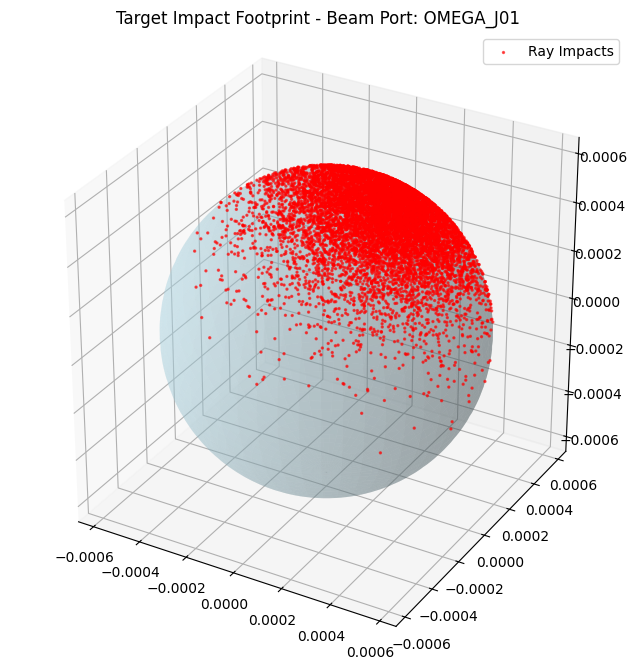

In [679]:
def plot_impact_footprint(impact_df, sphere_radius=TARGET_RADIUS):
    """
    Plots the 3D footprint of a single beam's rays on the target sphere.
    """
    # 1. Create 3D figure and axis
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # 2. Draw the SOLID colored sphere (target)
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x_sphere = sphere_radius * np.outer(np.cos(u), np.sin(v))
    y_sphere = sphere_radius * np.outer(np.sin(u), np.sin(v))
    z_sphere = sphere_radius * np.outer(np.ones_like(u), np.cos(v))
    
    # Surface plot with transparency to see impacts on both sides
    ax.plot_surface(x_sphere, y_sphere, z_sphere, 
                    color='lightblue', 
                    alpha=0.3,       # Transparency
                    linewidth=0, 
                    antialiased=True)

    # 3. Plot the impact points from the expanded DataFrame
    # Using the columns we just created: xsph_x, xsph_y, xsph_z
    xs = impact_df['xsph_x']
    ys = impact_df['xsph_y']
    zs = impact_df['xsph_z']
    
    # Scatter plot of the 10,000 rays (or as many as hit the target)
    ax.scatter(xs, ys, zs, color='red', s=2, alpha=0.6, label='Ray Impacts')

    # 4. Aesthetic configuration
    beam_id = impact_df['port'].iloc[0] if not impact_df.empty else "N/A"
    ax.set_title(f"Target Impact Footprint - Beam Port: {beam_id}")
    
    # Set axis limits to fit the sphere
    limit = sphere_radius * 1.1
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    
    # Set 1:1:1 aspect ratio so it looks like a sphere, not an egg
    ax.set_box_aspect([1, 1, 1])
    
    plt.legend()
    plt.show()

# --- Execution ---
# We use the expanded view we generated in the previous step
plot_impact_footprint(impact_1window_view, sphere_radius=TARGET_RADIUS)

## Simulation of hits from windows chosen by probability

### Simulation of impacts

In [680]:
def impact_simulated(
    num_beams_to_sample,
    num_samples_per_beam,
    target_radius,
    target_center
 ):
    # 1. USAR EL DATAFRAME EXPANDIDO
    # Usamos df_beams_vista que ya tiene 't1_x', 'focus_x', etc.
    beam_df = df_omega.copy() 

    # 2. Probabilidades según energía
    ps = np.array(beam_df['energy'], dtype=float)
    ps /= np.sum(ps)

    # 3. Selección aleatoria de haces (Monte Carlo)
    list_beams = np.arange(len(beam_df))
    selected_indices = np.random.choice(
        list_beams,
        size=num_beams_to_sample,
        p=ps
    )

    # 4. Simulación de impactos
    impact_list = []
    for i in selected_indices:
        # Extraemos la fila del haz seleccionado
        beam_row = beam_df.iloc[i]
        
        # Llamamos a beam_hit (que a su vez llama a beam_sample)
        # IMPORTANTE: center_target es el argumento de la función de trazado
        res = beam_hit(
            beam_row,
            num_samples_per_beam,
            radius=target_radius,
            center_target=target_center
        )
        
        if not res.empty:
            # Los metadatos ya deberían venir de beam_hit, pero aseguramos:
            res['port'] = beam_row['port']
            res['subwindow'] = beam_row['subwindow']
            impact_list.append(res)

    if not impact_list:
        print("Aviso: Ningún rayo impactó en el blanco.")
        return pd.DataFrame()

    # 5. Concatenar todos los DataFrames de impactos
    impact_df = pd.concat(impact_list, ignore_index=True)

    return impact_df

### Simulation parameters

In [681]:
# --- Ejecución ---
total_impact = impact_simulated(
    num_beams_to_sample=100,
    num_samples_per_beam=1000, 
    target_radius=TARGET_RADIUS,
    target_center=np.array([0.0, 0.0, 0.0])
)

print(f"Simulación masiva completada.")
print(f"Total de impactos registrados: {len(total_impact)}")

Simulación masiva completada.
Total de impactos registrados: 99623


### Information of impacts in dataframe

In [682]:
def impact_df_vista(df_in):
    """
    Función auxiliar para desglosar vectores en el DataFrame de impactos.
    """
    df = df_in.copy()
    
    # Función para expandir columnas vectoriales de forma eficiente
    def expand(df_target, col_name, names):
        if col_name in df_target.columns:
            temp = pd.DataFrame(df_target[col_name].tolist(), index=df_target.index)
            temp.columns = names
            return temp
        return pd.DataFrame()

    # Expandimos los vectores clave
    df_x = expand(df, 'x', ['x_x', 'x_y', 'x_z'])
    df_u = expand(df, 'u', ['u_x', 'u_y', 'u_z'])
    df_xsph = expand(df, 'xsph', ['xsph_x', 'xsph_y', 'xsph_z'])
    df_n = expand(df, 'n', ['n_x', 'n_y', 'n_z'])
    
    # Expandimos coordenadas esféricas (sph: r, theta, phi)
    df_sph = expand(df, 'sph', ['r', 'theta', 'phi'])

    # Concatenamos todo lo expandido con el original
    return pd.concat([df.drop(columns=['x', 'u', 'xsph', 'n', 'sph'], errors='ignore'), 
                      df_x, df_u, df_xsph, df_n, df_sph], axis=1)

def preparar_dataframe_impactos(impact_df):
    # 1. Expandir vectores y añadir coordenadas esféricas
    impact_df = impact_df_vista(impact_df)

    # 2. Asegurar columnas port y subwindow (evitar KeyErrors)
    if 'port' not in impact_df.columns: 
        impact_df['port'] = 'desconocido'
    if 'subwindow' not in impact_df.columns:
        impact_df['subwindow'] = 'desconocido'

    # 3. Seleccionar columnas relevantes siguiendo tu esquema
    cols = [
        'port', 'subwindow', 'l', 'cs', 'theta', 'phi',
        'x_x', 'x_y', 'x_z',
        'u_x', 'u_y', 'u_z',
        'xsph_x', 'xsph_y', 'xsph_z',
        'n_x', 'n_y', 'n_z'
    ]
    available_cols = [c for c in cols if c in impact_df.columns]

    # 4. Redondear y devolver DataFrame final
    # Usamos copy() para evitar el SettingWithCopyWarning
    formatted_df = impact_df[available_cols].copy()
    formatted_df = formatted_df.round(4)

    print(f"Impactos válidos encontrados: {len(formatted_df)}")
    return formatted_df

# --- Ejecución ---
df_impactos = preparar_dataframe_impactos(total_impact)
df_impactos

Impactos válidos encontrados: 99623


,port,subwindow,l,cs,theta,phi,x_x,x_y,x_z,u_x,u_y,u_z,xsph_x,xsph_y,xsph_z,n_x,n_y,n_z
0,OMEGA_J53,0,1.6496,-0.9346,2.6821,2.4478,0.8545,-0.8507,-1.1266,-0.5179,0.5156,0.6826,0.0002,-0.0002,-0.0005,0.3410,-0.2836,-0.8963
1,OMEGA_J53,0,1.6496,-0.9352,2.0855,1.9778,0.8548,-0.8853,-1.0995,-0.5180,0.5363,0.6663,0.0002,-0.0005,-0.0003,0.3446,-0.7993,-0.4923
2,OMEGA_J53,0,1.6495,-0.9806,2.1063,2.4092,0.8728,-0.8685,-1.0985,-0.5289,0.5263,0.6658,0.0004,-0.0003,-0.0003,0.6395,-0.5751,-0.5102
3,OMEGA_J53,0,1.6496,-0.9446,2.5665,2.7214,0.8646,-0.8462,-1.1223,-0.5239,0.5129,0.6800,0.0003,-0.0001,-0.0005,0.4966,-0.2219,-0.8392
4,OMEGA_J53,0,1.6495,-0.9779,2.1194,2.4978,0.8758,-0.8644,-1.0994,-0.5307,0.5238,0.6663,0.0004,-0.0003,-0.0003,0.6825,-0.5122,-0.5215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99618,OMEGA_J50,0,1.6494,-0.9858,2.4661,0.6756,-0.8625,-0.8560,-1.1163,0.5227,0.5188,0.6765,-0.0003,-0.0002,-0.0005,-0.4879,-0.3910,-0.7804
99619,OMEGA_J50,0,1.6495,-0.9564,2.0017,0.8376,-0.8716,-0.8761,-1.0934,0.5282,0.5309,0.6627,-0.0004,-0.0004,-0.0003,-0.6081,-0.6751,-0.4177
99620,OMEGA_J50,0,1.6504,-0.6868,1.8420,6.2438,-0.9060,-0.8382,-1.0962,0.5486,0.5079,0.6641,-0.0006,0.0000,-0.0002,-0.9627,0.0380,-0.2679
99621,OMEGA_J50,0,1.6497,-0.9127,2.6810,1.1806,-0.8438,-0.8601,-1.1276,0.5114,0.5212,0.6832,-0.0001,-0.0002,-0.0005,-0.1691,-0.4111,-0.8958


## Histogram of impacts in a 1m radius sphere

### Divides the sphere in sectors

In [683]:
class SphereSectors():
    def __init__(self, num_theta, num_phi):
      # mesh in theta-phi
      self.theta_edges = np.linspace(0, np.pi, num_theta + 1)  # incluye polos
      self.phi_edges = np.linspace(0, 2 * np.pi, num_phi + 1)  # incluye cierre

      # coordinates of the spherical sector center
      self.theta = 0.5 * (self.theta_edges[:-1] + self.theta_edges[1:])
      self.phi = 0.5 * (self.phi_edges[:-1] + self.phi_edges[1:])

      self.mtheta, self.mphi = np.meshgrid(self.theta, self.phi, indexing='ij')       

      return

sectors = SphereSectors( num_theta = 50, num_phi = 50)

### Representation of the mesh

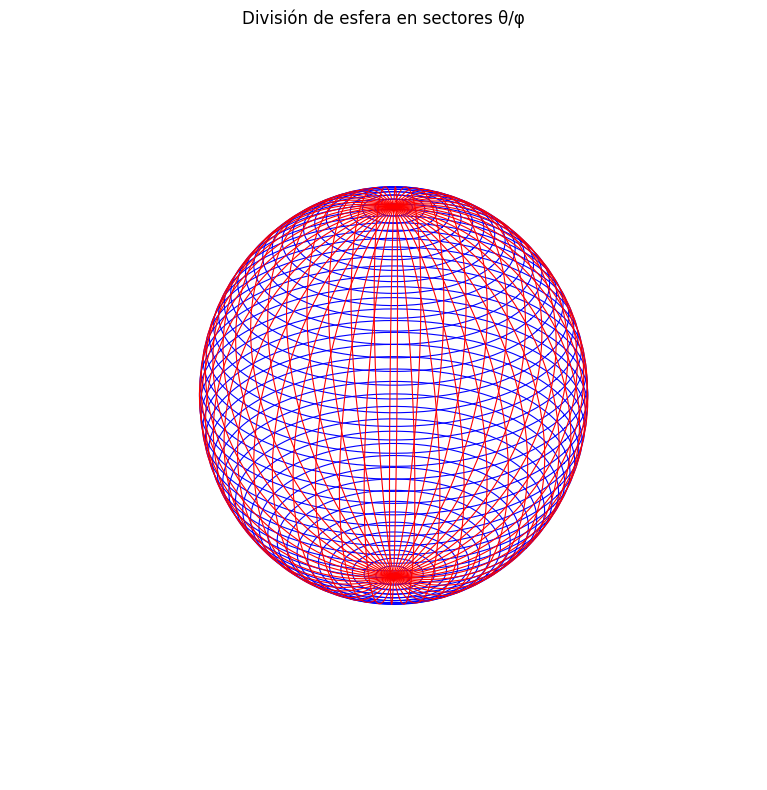

In [684]:
# Parámetros
radius = TARGET_RADIUS

# Crear figura 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Dibujar líneas horizontales (theta)
phi = np.linspace(0, 2 * np.pi, 200)
for theta in sectors.theta:
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    ax.plot(x, y, z, color='blue', linewidth=0.8)

# Dibujar líneas verticales (phi)
theta = np.linspace(0, np.pi, 200)
for phi in sectors.phi:
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    ax.plot(x, y, z, color='red', linewidth=0.8)

# Estética
ax.set_box_aspect([1, 1, 1])
ax.set_title("División de esfera en sectores θ/φ")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Function to calculate the area of sectors of the mesh

In [685]:
def spherical_sector_area( theta1, theta2, phi1, phi2, radius=1., ):
    area_anillo = 2 * np.pi * radius**2 * np.abs(np.cos(theta1) - np.cos(theta2))
    delta_phi = np.abs(phi2 - phi1)
    area_sector = (delta_phi / (2 * np.pi)) * area_anillo
    return area_sector

sectors.area = spherical_sector_area( sectors.theta_edges[:-1][:,None], sectors.theta_edges[1:][:,None], sectors.phi_edges[:-1][None,:], sectors.phi_edges[1:][None,:], radius=1., )

assert np.isclose( np.sum( sectors.area ), 4.*np.pi, atol=1e-4 ), "El área total calculada no coincide con el área de la esfera."

### Plots the centers of each sector in the sphere mesh

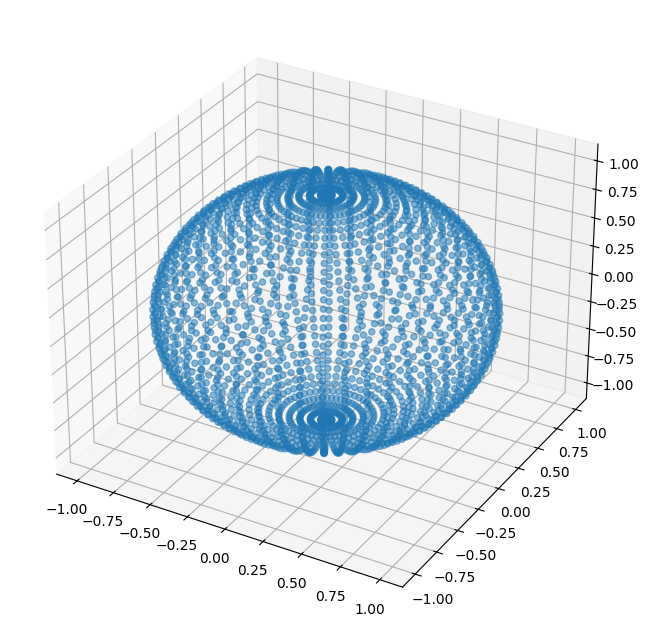

In [686]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(111, projection='3d')

xs, ys, zs = sph_to_cart(1.0, sectors.mtheta, sectors.mphi)
ax.scatter( xs, ys, zs, alpha=0.5)

### Creates energy histogram in sphere

In [687]:
def hist(hits, sectors):
    # Histograma 2D con pesos
    hs_raw, _, _ = np.histogram2d(
        hits['theta'],
        hits['phi'],
        bins=[sectors.theta_edges, sectors.phi_edges],
        weights=np.abs(hits['cs'])
    )

    # Densidad por unidad de área
    hs = hs_raw / sectors.area

    # Validación de conservación
    assert np.isclose(
        np.sum(hs * sectors.area),
        np.sum(np.abs(hits['cs'])),
        atol=1e-4
    ), "La suma ponderada no coincide con la suma original de |cs|."

    # Normalización para visualización
    hs_norm = (hs - np.min(hs)) / (np.max(hs) - np.min(hs))

    # DataFrame final
    df_hist = pd.DataFrame({
        'theta': sectors.mtheta.ravel(),
        'phi': sectors.mphi.ravel(),
        'hs_raw': hs_raw.ravel(),
        'hs_density': hs.ravel(),
        'hs_norm': hs_norm.ravel()
    })

    return df_hist

In [688]:
hits = df_impactos[df_impactos['cs'] < 0]

In [689]:
df_hist = hist(hits, sectors)

hs = df_hist['hs_density'].values

### Histogram graphic

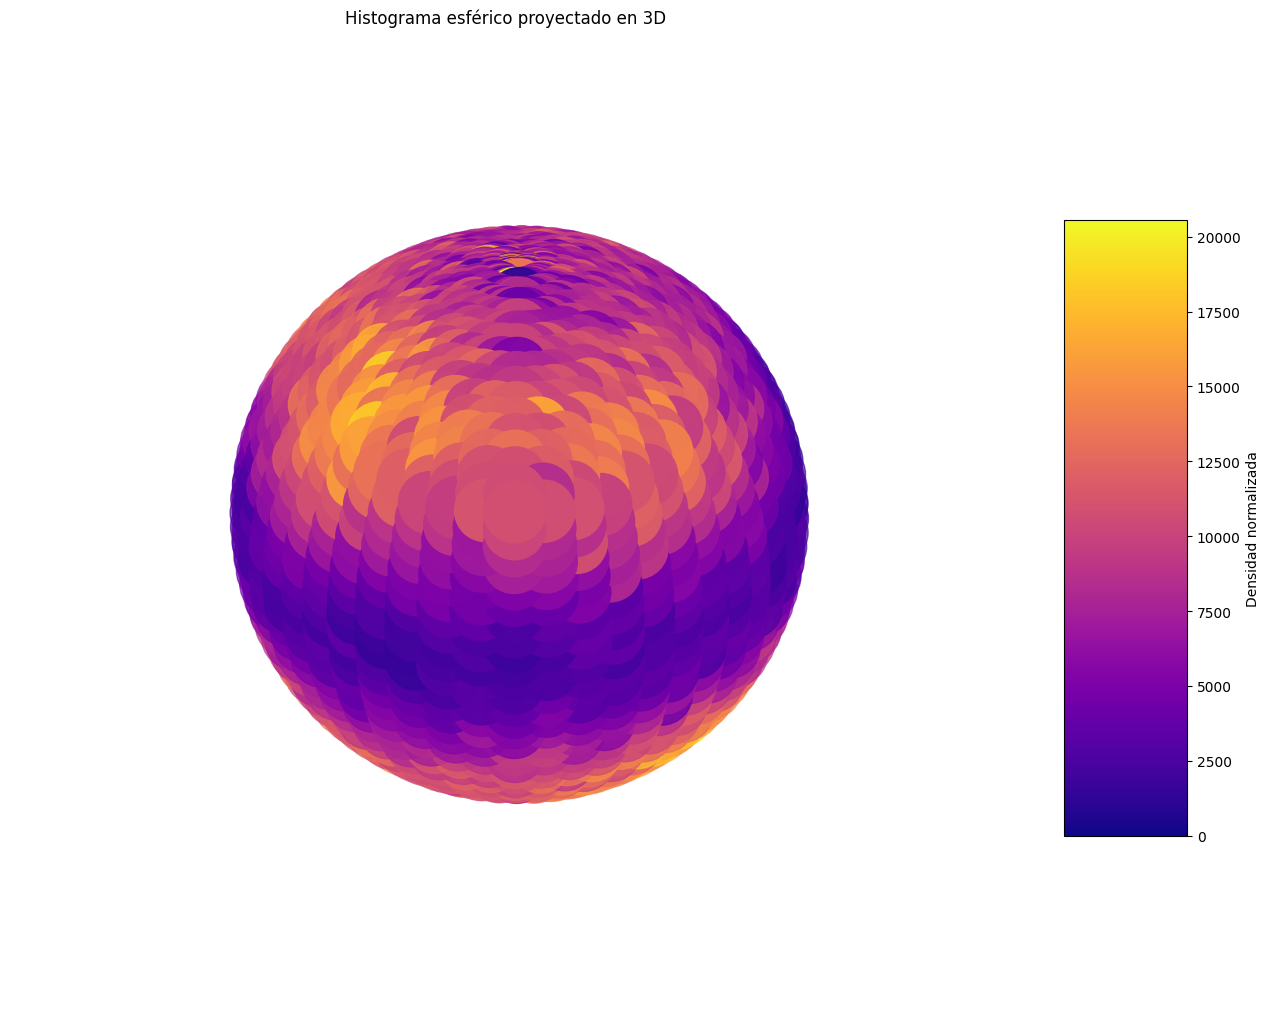

In [690]:
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')

# Convertir centros de sector a coordenadas cartesianas
xs, ys, zs = sph_to_cart(1.0, sectors.mtheta, sectors.mphi)

# Aplanar para scatter
X = xs.ravel()
Y = ys.ravel()
Z = zs.ravel()
C = hs.ravel()   # hs debe ser el histograma normalizado o densidad

# Plot
p = ax.scatter(X, Y, Z, c=C, cmap='plasma', s=2000)

# Colorbar
cb = fig.colorbar(p, ax=ax, shrink=0.5, aspect=5)
cb.set_label("Densidad normalizada")

ax.set_box_aspect([1, 1, 1])
ax.set_title("Histograma esférico proyectado en 3D")
ax.set_axis_off()

plt.show()

### Pyvista histogram graphic

### Import to rwhist file